In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import os
import warnings
warnings.filterwarnings('ignore')

# Path to your data
data_path = r"E:\Github_Projects\openpmx\data"

print("All libraries loaded!")
print("Ready to build anomaly detection model")

All libraries loaded!
Ready to build anomaly detection model


In [2]:
# Load all snapshots from 1st_test and calculate RMS for each bearing
first_folder = os.path.join(data_path, "1st_test", "1st_test")
all_files = sorted(os.listdir(first_folder))

# Store RMS values for all 4 bearings over time
records = []

for file in all_files:
    file_path = os.path.join(first_folder, file)
    data = pd.read_csv(file_path, sep="\t", header=None)
    
    record = {
        "timestamp": file,
        "bearing1_rms": np.sqrt(np.mean(data.iloc[:, 0]**2)),
        "bearing2_rms": np.sqrt(np.mean(data.iloc[:, 2]**2)),
        "bearing3_rms": np.sqrt(np.mean(data.iloc[:, 4]**2)),
        "bearing4_rms": np.sqrt(np.mean(data.iloc[:, 6]**2))
    }
    records.append(record)

# Convert to dataframe
df = pd.DataFrame(records)

print(f"Total snapshots loaded: {len(df)}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nLast 5 rows:")
print(df.tail())

Total snapshots loaded: 2156

First 5 rows:
             timestamp  bearing1_rms  bearing2_rms  bearing3_rms  bearing4_rms
0  2003.10.22.12.06.24      0.124614      0.130455      0.128887      0.109020
1  2003.10.22.12.09.13      0.123811      0.131490      0.129562      0.108900
2  2003.10.22.12.14.13      0.125246      0.131906      0.131339      0.110319
3  2003.10.22.12.19.13      0.125197      0.131614      0.131083      0.111037
4  2003.10.22.12.24.13      0.125618      0.130779      0.131307      0.110190

Last 5 rows:
                timestamp  bearing1_rms  bearing2_rms  bearing3_rms  \
2151  2003.11.25.16.07.32      0.168639      0.187779      0.275645   
2152  2003.11.25.23.13.21      0.174975      0.201525      0.496173   
2153  2003.11.25.23.19.56      0.174571      0.207927      0.531569   
2154  2003.11.25.23.29.56      0.173471      0.196989      0.474447   
2155  2003.11.25.23.39.56      0.174181      0.211860      0.593610   

      bearing4_rms  
2151      0.207455  

In [3]:
# Use only the first 1000 snapshots as "normal" data to train on
# This is when the bearings were healthy
normal_data = df[["bearing1_rms", "bearing2_rms", 
                   "bearing3_rms", "bearing4_rms"]].values[:1000]

# Scale the data - ML models work better with normalized values
scaler = StandardScaler()
normal_data_scaled = scaler.fit_transform(normal_data)

# Train Isolation Forest
# contamination=0.05 means we expect ~5% of data to be anomalies
model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)
model.fit(normal_data_scaled)

print("Model trained successfully!")
print(f"Trained on {len(normal_data)} healthy snapshots")
print(f"Features used: bearing1_rms, bearing2_rms, bearing3_rms, bearing4_rms")

Model trained successfully!
Trained on 1000 healthy snapshots
Features used: bearing1_rms, bearing2_rms, bearing3_rms, bearing4_rms


In [4]:
# Run model on all 2156 snapshots
all_data = df[["bearing1_rms", "bearing2_rms",
               "bearing3_rms", "bearing4_rms"]].values

# Scale using the same scaler trained on normal data
all_data_scaled = scaler.transform(all_data)

# Predict — model returns 1 for normal, -1 for anomaly
predictions = model.predict(all_data_scaled)
anomaly_scores = model.decision_function(all_data_scaled)

# Add results to dataframe
df["anomaly"] = predictions
df["anomaly_score"] = anomaly_scores
df["is_anomaly"] = df["anomaly"] == -1

# Summary
total = len(df)
anomalies = df["is_anomaly"].sum()
first_anomaly = df[df["is_anomaly"]].index[0]

print(f"Total snapshots: {total}")
print(f"Anomalies detected: {anomalies}")
print(f"First anomaly detected at snapshot: {first_anomaly}")
print(f"First anomaly timestamp: {df.loc[first_anomaly, 'timestamp']}")
print(f"\nBearing 3 RMS at first anomaly: {df.loc[first_anomaly, 'bearing3_rms']:.4f}g")
print(f"Bearing 3 RMS at failure: {df['bearing3_rms'].iloc[-1]:.4f}g")

Total snapshots: 2156
Anomalies detected: 611
First anomaly detected at snapshot: 0
First anomaly timestamp: 2003.10.22.12.06.24

Bearing 3 RMS at first anomaly: 0.1289g
Bearing 3 RMS at failure: 0.5936g


In [5]:
# Problem: contamination=0.05 is too sensitive
# Fix: train on more data and reduce contamination

# Use first 1500 snapshots as normal (bearings were healthy longer)
normal_data = df[["bearing1_rms", "bearing2_rms",
                   "bearing3_rms", "bearing4_rms"]].values[:1500]

# Rescale
scaler = StandardScaler()
normal_data_scaled = scaler.fit_transform(normal_data)

# Retrain with lower contamination
model = IsolationForest(
    n_estimators=200,
    contamination=0.01,  # reduced from 0.05 to 0.01
    random_state=42
)
model.fit(normal_data_scaled)

# Rerun predictions
all_data_scaled = scaler.transform(all_data)
predictions = model.predict(all_data_scaled)
anomaly_scores = model.decision_function(all_data_scaled)

df["anomaly"] = predictions
df["anomaly_score"] = anomaly_scores
df["is_anomaly"] = df["anomaly"] == -1

# Summary
anomalies = df["is_anomaly"].sum()
first_anomaly = df[df["is_anomaly"]].index[0]

print(f"Total snapshots: {total}")
print(f"Anomalies detected: {anomalies}")
print(f"First anomaly detected at snapshot: {first_anomaly}")
print(f"First anomaly timestamp: {df.loc[first_anomaly, 'timestamp']}")
print(f"Bearing 3 RMS at first anomaly: {df.loc[first_anomaly, 'bearing3_rms']:.4f}g")
print(f"Bearing 3 RMS at failure: {df['bearing3_rms'].iloc[-1]:.4f}g")

Total snapshots: 2156
Anomalies detected: 422
First anomaly detected at snapshot: 0
First anomaly timestamp: 2003.10.22.12.06.24
Bearing 3 RMS at first anomaly: 0.1289g
Bearing 3 RMS at failure: 0.5936g


In [6]:
# Calculate baseline statistics from first 500 snapshots
baseline = df[["bearing1_rms", "bearing2_rms",
               "bearing3_rms", "bearing4_rms"]].values[:500]

baseline_mean = baseline.mean(axis=0)
baseline_std = baseline.std(axis=0)

# Set threshold at 3 standard deviations above normal
threshold = baseline_mean + 3 * baseline_std

print("Baseline mean RMS per bearing:")
for i, mean in enumerate(baseline_mean):
    print(f"  Bearing {i+1}: {mean:.4f}g")

print("\nAnomaly threshold (3 std above normal):")
for i, thresh in enumerate(threshold):
    print(f"  Bearing {i+1}: {thresh:.4f}g")

# Detect anomalies based on threshold
df["b1_anomaly"] = df["bearing1_rms"] > threshold[0]
df["b2_anomaly"] = df["bearing2_rms"] > threshold[1]
df["b3_anomaly"] = df["bearing3_rms"] > threshold[2]
df["b4_anomaly"] = df["bearing4_rms"] > threshold[3]

# Flag if ANY bearing exceeds threshold
df["is_anomaly"] = (df["b1_anomaly"] | df["b2_anomaly"] | 
                    df["b3_anomaly"] | df["b4_anomaly"])

# Find first real anomaly
first_anomaly = df[df["is_anomaly"]].index[0]
first_timestamp = df.loc[first_anomaly, "timestamp"]
last_timestamp = df["timestamp"].iloc[-1]

print(f"\nTotal anomalies detected: {df['is_anomaly'].sum()}")
print(f"First anomaly at snapshot: {first_anomaly}")
print(f"First anomaly timestamp: {first_timestamp}")
print(f"Failure timestamp: {last_timestamp}")
print(f"\nBearing 3 RMS at first anomaly: {df.loc[first_anomaly, 'bearing3_rms']:.4f}g")
print(f"Bearing 3 RMS at failure: {df['bearing3_rms'].iloc[-1]:.4f}g")

Baseline mean RMS per bearing:
  Bearing 1: 0.1439g
  Bearing 2: 0.1443g
  Bearing 3: 0.1507g
  Bearing 4: 0.1302g

Anomaly threshold (3 std above normal):
  Bearing 1: 0.1755g
  Bearing 2: 0.1705g
  Bearing 3: 0.1900g
  Bearing 4: 0.1731g

Total anomalies detected: 376
First anomaly at snapshot: 24
First anomaly timestamp: 2003.10.22.14.04.13
Failure timestamp: 2003.11.25.23.39.56

Bearing 3 RMS at first anomaly: 0.1317g
Bearing 3 RMS at failure: 0.5936g


In [7]:
# Check which bearing triggered the first anomaly
first = df.iloc[24]

print("Snapshot 24 — First anomaly details:")
print(f"Timestamp: {first['timestamp']}")
print(f"Bearing 1 RMS: {first['bearing1_rms']:.4f}g  (threshold: {threshold[0]:.4f}g)  Anomaly: {first['b1_anomaly']}")
print(f"Bearing 2 RMS: {first['bearing2_rms']:.4f}g  (threshold: {threshold[1]:.4f}g)  Anomaly: {first['b2_anomaly']}")
print(f"Bearing 3 RMS: {first['bearing3_rms']:.4f}g  (threshold: {threshold[2]:.4f}g)  Anomaly: {first['b3_anomaly']}")
print(f"Bearing 4 RMS: {first['bearing4_rms']:.4f}g  (threshold: {threshold[3]:.4f}g)  Anomaly: {first['b4_anomaly']}")

# Find when Bearing 3 specifically first triggered
b3_first = df[df["b3_anomaly"]].index[0]
print(f"\nBearing 3 first anomaly at snapshot: {b3_first}")
print(f"Bearing 3 first anomaly timestamp: {df.loc[b3_first, 'timestamp']}")
print(f"Bearing 3 RMS at that point: {df.loc[b3_first, 'bearing3_rms']:.4f}g")

# Calculate days of warning
from datetime import datetime
b3_warning = datetime.strptime(df.loc[b3_first, "timestamp"], "%Y.%m.%d.%H.%M.%S")
failure = datetime.strptime(df["timestamp"].iloc[-1], "%Y.%m.%d.%H.%M.%S")
days_warning = (failure - b3_warning).days

print(f"\nDays of advance warning for Bearing 3: {days_warning} days")

Snapshot 24 — First anomaly details:
Timestamp: 2003.10.22.14.04.13
Bearing 1 RMS: 0.1256g  (threshold: 0.1755g)  Anomaly: False
Bearing 2 RMS: 0.1312g  (threshold: 0.1705g)  Anomaly: False
Bearing 3 RMS: 0.1317g  (threshold: 0.1900g)  Anomaly: False
Bearing 4 RMS: 0.2373g  (threshold: 0.1731g)  Anomaly: True

Bearing 3 first anomaly at snapshot: 2055
Bearing 3 first anomaly timestamp: 2003.11.24.13.27.32
Bearing 3 RMS at that point: 0.1912g

Days of advance warning for Bearing 3: 1 days


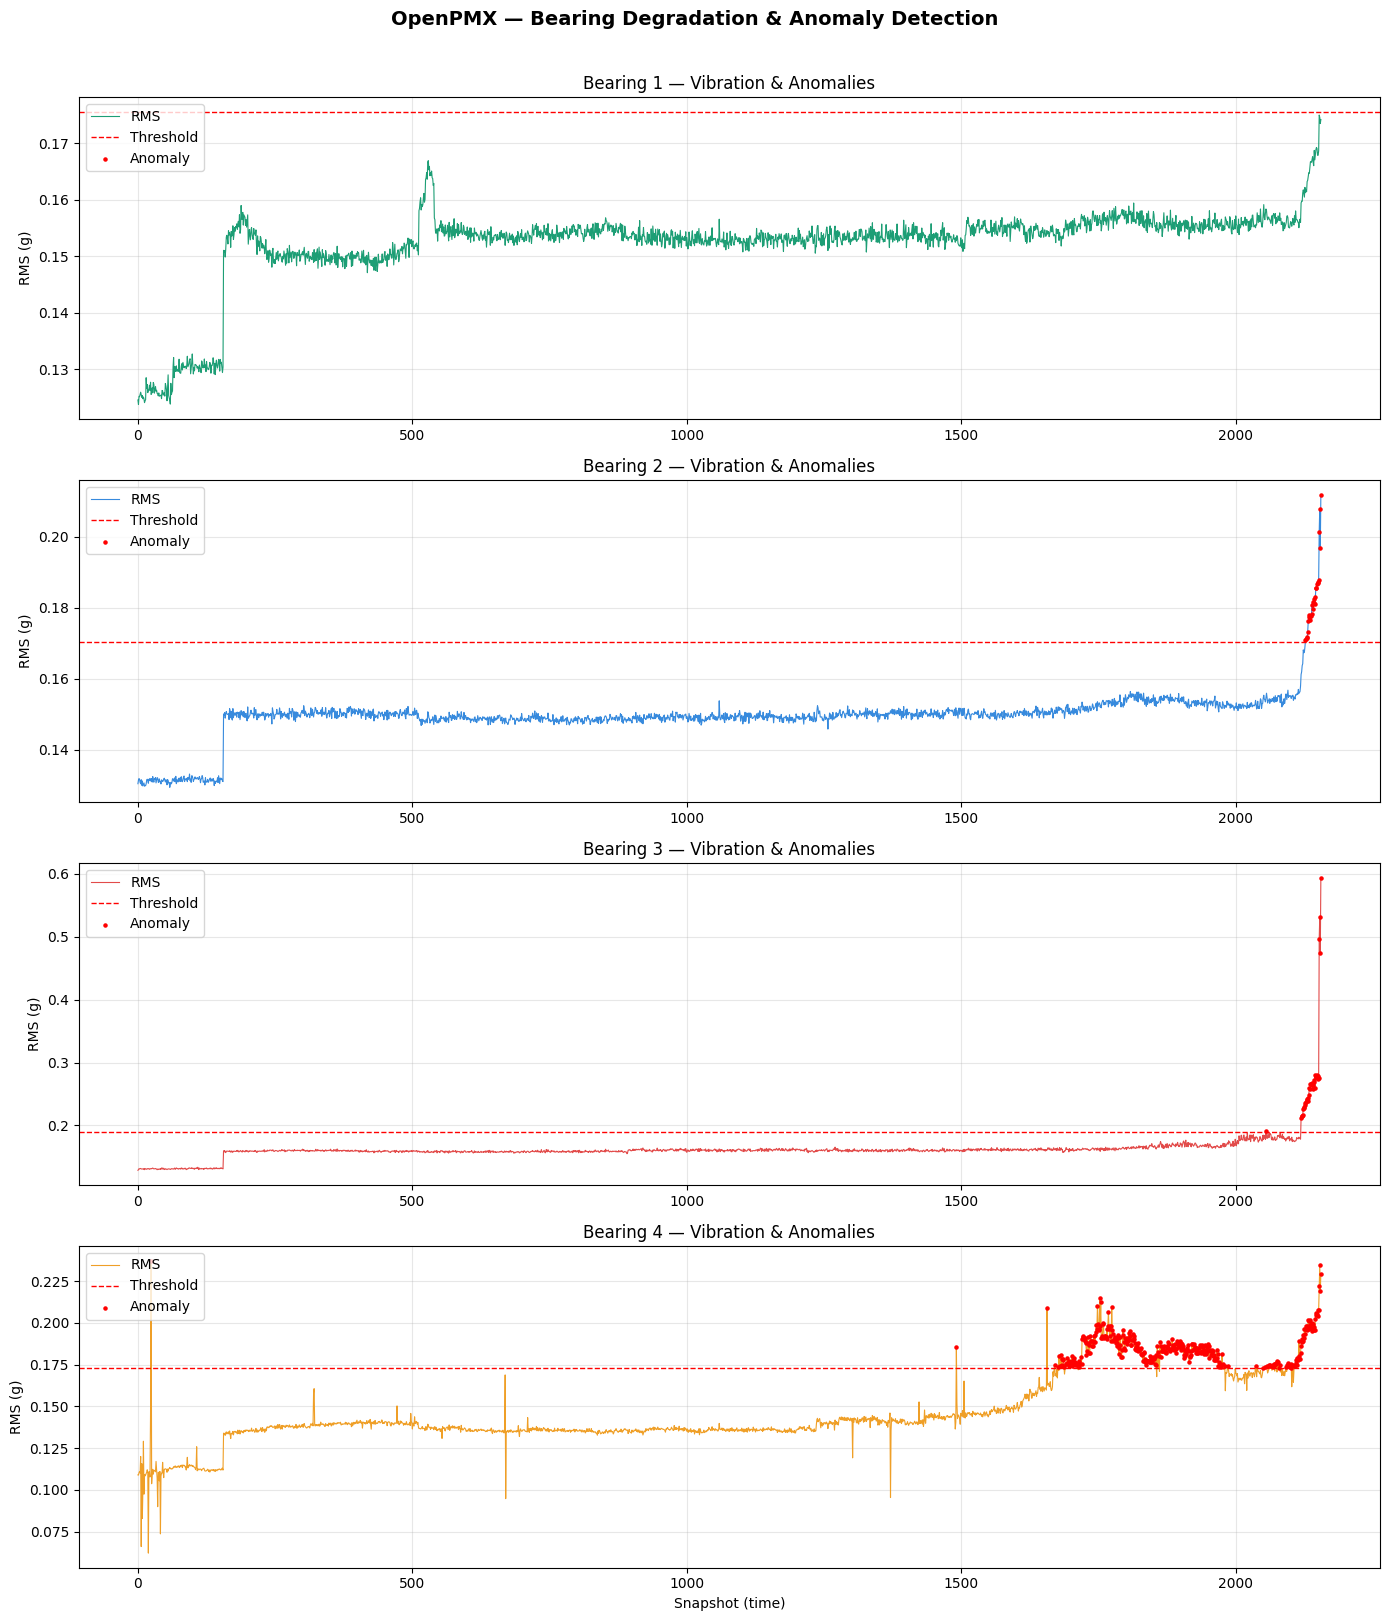

Chart saved as bearing_anomaly_detection.png


In [8]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16))

bearings = ["bearing1_rms", "bearing2_rms", "bearing3_rms", "bearing4_rms"]
colors = ["#1D9E75", "#378ADD", "#E24B4A", "#EF9F27"]
anomaly_cols = ["b1_anomaly", "b2_anomaly", "b3_anomaly", "b4_anomaly"]

for i, (bearing, color, anomaly_col) in enumerate(zip(bearings, colors, anomaly_cols)):
    ax = axes[i]
    
    # Plot RMS over time
    ax.plot(df.index, df[bearing], color=color, linewidth=0.8, label="RMS")
    
    # Plot threshold line
    ax.axhline(y=threshold[i], color="red", linestyle="--", 
               linewidth=1, label="Threshold")
    
    # Highlight anomaly regions
    anomaly_points = df[df[anomaly_col]]
    ax.scatter(anomaly_points.index, anomaly_points[bearing],
               color="red", s=5, zorder=5, label="Anomaly")
    
    ax.set_title(f"Bearing {i+1} — Vibration & Anomalies")
    ax.set_ylabel("RMS (g)")
    ax.legend(loc="upper left")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Snapshot (time)")
plt.suptitle("OpenPMX — Bearing Degradation & Anomaly Detection", 
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("bearing_anomaly_detection.png", dpi=150, bbox_inches="tight")
plt.show()

print("Chart saved as bearing_anomaly_detection.png")